# HCC Study

In [1]:
import numpy as np
import pandas as pd
import random
import math
import seaborn as sns
import scipy.stats as stats
import torch
import networkx as nx
from metvae.model import MetVAE

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
%matplotlib inline

## Data Import

### MS1 Data

In [2]:
# MS1 data
df_ms1 = pd.read_csv('../data/hcc/hcc_ms1.csv', index_col=0)
df_ms1.index = df_ms1.index.astype(str)
df_ms1.head()

,row m/z,row retention time,correlation group ID,annotation network number,best ion,auto MS2 verify,identified by n=,partners,neutral M mass,SS143_RE2_01_7471.mzXML Peak area,...,SS91_RH7_01_7408.mzXML Peak area,SS65_RF5_01_7378.mzXML Peak area,SS4_RA4_01_7308.mzXML Peak area,SS39_RD3_01_7349.mzXML Peak area,SS85_RH1_01_7401.mzXML Peak area,SS78_RG6_01_7393.mzXML Peak area,SS8_RA8_01_7314.mzXML Peak area,SS53_RE5_01_7365.mzXML Peak area,SS93_RH9_01_7410.mzXML Peak area,Unnamed: 449
row ID,,,,,,,,,,,,,,,,,,,,,
1,90.507336,14.711031,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.729032e+04,...,3.984643e+04,6.207472e+04,4.711460e+04,3.124769e+04,3.695430e+04,4.775607e+04,5.016101e+04,4.273617e+04,4.289156e+04,NaN
2,97.009823,14.711820,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.621003e+04,...,5.497772e+04,5.006906e+04,2.637787e+04,5.162720e+04,4.703117e+04,4.765542e+04,5.089295e+04,3.949850e+04,4.294513e+04,NaN
3,98.512122,14.871233,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.706221e+06,...,3.979941e+06,3.273772e+06,3.317892e+06,3.790327e+06,3.190978e+06,4.089099e+06,3.674933e+06,2.902031e+06,3.421487e+06,NaN
4,99.512410,11.727107,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.912212e+05,...,5.256321e+04,3.109291e+04,1.983272e+04,6.152516e+04,1.135546e+05,6.762894e+04,3.816150e+04,1.274469e+04,5.170462e+04,NaN
5,99.512521,14.708522,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.073736e+05,...,5.746619e+05,5.285471e+05,4.880767e+05,5.344626e+05,5.678752e+05,5.615138e+05,7.487015e+05,4.981058e+05,5.575404e+05,NaN


In [3]:
df_ms1 = df_ms1.iloc[:, 9:]
df_ms1.columns = list(map(lambda x: x.split('_')[0], df_ms1.columns))
df_ms1.head()

,SS143,SS120,SS123,SS155,SS141,SS121,SS140,SS124,SS15,SS138,...,SS91,SS65,SS4,SS39,SS85,SS78,SS8,SS53,SS93,Unnamed: 449
row ID,,,,,,,,,,,,,,,,,,,,,
1,2.729032e+04,1.928039e+04,2.728180e+04,4.682497e+04,3.178914e+04,2.114912e+04,3.165295e+04,2.521755e+04,6.261658e+04,2.758604e+04,...,3.984643e+04,6.207472e+04,4.711460e+04,3.124769e+04,3.695430e+04,4.775607e+04,5.016101e+04,4.273617e+04,4.289156e+04,NaN
2,3.621003e+04,2.916010e+04,3.260775e+04,3.791754e+04,3.729399e+04,3.075806e+04,3.240898e+04,3.596255e+04,5.062035e+04,3.624059e+04,...,5.497772e+04,5.006906e+04,2.637787e+04,5.162720e+04,4.703117e+04,4.765542e+04,5.089295e+04,3.949850e+04,4.294513e+04,NaN
3,1.706221e+06,1.884450e+06,1.894575e+06,1.718484e+06,1.649212e+06,2.055684e+06,1.776700e+06,1.942272e+06,4.060275e+06,1.619489e+06,...,3.979941e+06,3.273772e+06,3.317892e+06,3.790327e+06,3.190978e+06,4.089099e+06,3.674933e+06,2.902031e+06,3.421487e+06,NaN
4,6.912212e+05,5.970162e+04,5.051051e+04,1.590103e+05,7.749228e+04,2.963356e+04,4.969034e+04,8.824638e+04,5.354826e+04,8.622156e+04,...,5.256321e+04,3.109291e+04,1.983272e+04,6.152516e+04,1.135546e+05,6.762894e+04,3.816150e+04,1.274469e+04,5.170462e+04,NaN
5,4.073736e+05,3.528370e+05,4.583009e+05,4.848497e+05,4.614917e+05,3.818776e+05,4.042722e+05,4.128373e+05,6.833594e+05,4.549129e+05,...,5.746619e+05,5.285471e+05,4.880767e+05,5.344626e+05,5.678752e+05,5.615138e+05,7.487015e+05,4.981058e+05,5.575404e+05,NaN


### MS2 Data

In [4]:
df_ms2 = pd.read_table('../data/hcc/hcc_ms2.tsv')
df_ms2 = df_ms2.set_index('#Scan#')
df_ms2.index = df_ms2.index.astype(str)
df_ms2.sort_values(by="Compound_Name", inplace=True)
df_ms2.head()

,SpectrumID,Compound_Name,Ion_Source,Instrument,Compound_Source,PI,Data_Collector,Adduct,Precursor_MZ,ExactMass,...,MoleculeExplorerDatasets,MoleculeExplorerFiles,InChIKey,InChIKey-Planar,superclass,class,subclass,npclassifier_superclass,npclassifier_class,npclassifier_pathway
#Scan#,,,,,,,,,,,,,,,,,,,,,
2956,CCMSLIB00005465060,"""(4R)-4-((3R,5R,6R,7S,9S,10R,12S,13R,14S,17R)-...",ESI,qTof,crude,Dorrestein,Emily Gentry,2M+H,849.572,424.283,...,0,0,COCMFMBNEAMQMA-NQTCFNIESA-N,COCMFMBNEAMQMA,NaN,NaN,NaN,Steroids,Cholane steroids,Terpenoids
6504,CCMSLIB00005465106,"""(4R)-4-((3R,5R,6S,7R,9S,10R,12S,13R,14S,17R)-...",ESI,qTof,crude,Dorrestein,Emily Gentry,2M+H,849.572,424.283,...,0,0,COCMFMBNEAMQMA-KREOYVNCSA-N,COCMFMBNEAMQMA,NaN,NaN,NaN,Steroids,Cholane steroids,Terpenoids
4718,CCMSLIB00005465106,"""(4R)-4-((3R,5R,6S,7R,9S,10R,12S,13R,14S,17R)-...",ESI,qTof,crude,Dorrestein,Emily Gentry,2M+H,849.572,424.283,...,0,0,COCMFMBNEAMQMA-KREOYVNCSA-N,COCMFMBNEAMQMA,NaN,NaN,NaN,Steroids,Cholane steroids,Terpenoids
4378,CCMSLIB00005465007,"""(4R)-4-((3R,5R,6S,7R,9S,10R,12S,13R,14S,17R)-...",ESI,qTof,crude,Dorrestein,Emily Gentry,2M+H,849.572,424.283,...,0,0,COCMFMBNEAMQMA-KREOYVNCSA-N,COCMFMBNEAMQMA,NaN,NaN,NaN,Steroids,Cholane steroids,Terpenoids
4796,CCMSLIB00005465007,"""(4R)-4-((3R,5R,6S,7R,9S,10R,12S,13R,14S,17R)-...",ESI,qTof,crude,Dorrestein,Emily Gentry,2M+H,849.572,424.283,...,0,0,COCMFMBNEAMQMA-KREOYVNCSA-N,COCMFMBNEAMQMA,NaN,NaN,NaN,Steroids,Cholane steroids,Terpenoids


### Sample Metadata

In [5]:
smd = pd.read_table('../data/hcc/hcc_sample_metadata.txt')
smd.set_index('host_subject_id', inplace=True)
smd.head()

,age,age_units,antibiotics,body_habitat,body_product,body_site,cage,collection_timestamp,description,diet,...,FVB,IgA,IgM,CD8KO,HCC,SI,T1d,TGFbRflox/flox,TGFbrko,NASH
host_subject_id,,,,,,,,,,,,,,,,,,,,,
SS1,27,weeks,No,UBERON:gastro-intestinal system,UBERON:feces,UBERON:colon,Cage 1,2016-05-05,MupHe-HFD (6M),HFD,...,False,True,True,False,False,False,False,False,False,True
SS10,27,weeks,No,UBERON:gastro-intestinal system,UBERON:feces,UBERON:colon,Cage 4,2016-06-20,MupHe-HFD (6M),HFD,...,False,True,True,False,False,False,False,False,False,True
SS100,28,weeks,No,UBERON:gastro-intestinal system,UBERON:feces,UBERON:colon,Cage 49,2016-06-30,IgAkMup-HFD (6M),HFD,...,False,False,True,False,False,False,False,False,False,True
SS101,27,weeks,No,UBERON:gastro-intestinal system,UBERON:feces,UBERON:colon,Cage 50,2016-06-30,IgAkMup-HFD (6M),HFD,...,False,False,True,False,False,False,False,False,False,True
SS102,27,weeks,No,UBERON:gastro-intestinal system,UBERON:feces,UBERON:colon,Cage 50,2016-06-30,IgAkMup-HFD (6M),HFD,...,False,False,True,False,False,False,False,False,False,True


In [6]:
smd.columns

Index(['age', 'age_units', 'antibiotics', 'body_habitat', 'body_product',
       'body_site', 'cage', 'collection_timestamp', 'description', 'diet',
       'dna_extracted', 'elevation', 'env_biome', 'env_feature',
       'env_material', 'env_package', 'experiment_group', 'geo_loc_name',
       'host_scientific_name', 'host_taxid', 'immune_status', 'latitude',
       'life_stage', 'longitude', 'mice_group', 'number', 'number2',
       'phenotype', 'physical_specimen_location',
       'physical_specimen_remaining', 'qiita_study_id', 'sample_type',
       'scientific_name', 'sex', 'strain', 'taxon_id', 'timepoint', 'title',
       'weight', 'weight_unit', 'obese', 'adenomas', 'ABX', 'FVB', 'IgA',
       'IgM', 'CD8KO', 'HCC', 'SI', 'T1d', 'TGFbRflox/flox', 'TGFbrko',
       'NASH'],
      dtype='object')

In [7]:
smd['HCC'] = smd['HCC'].map({True: 'Yes', False: 'No'})
smd['HCC'].value_counts()

HCC
No     244
Yes    208
Name: count, dtype: int64

In [8]:
smd['diet'].value_counts()

diet
HFD    338
NC     114
Name: count, dtype: int64

In [9]:
smd['antibiotics'] = smd['antibiotics'].str.strip().replace(
    {'Yes (Ampicillin, Vancomycin, Neomycin sulfate and Metronidazole )': 'Yes'}
)
smd['antibiotics'].value_counts()

antibiotics
No     425
Yes     27
Name: count, dtype: int64

In [10]:
smd[['age']].describe()

,age
count,452.000000
mean,35.402655
std,13.641166
min,5.000000
25%,25.000000
50%,39.500000
75%,48.000000
max,56.000000


In [11]:
pd.crosstab(smd['HCC'], smd['diet'], margins='True')

diet,HFD,NC,All
HCC,,,
No,139,105,244
Yes,199,9,208
All,338,114,452


### Pre-processing

In [12]:
# --- Baselines ---
ms1_cols_before = df_ms1.columns
n_ms1_before = len(ms1_cols_before)
n_meta_before = smd.shape[0]

print(f"Start — MS1 sample columns: {n_ms1_before}, metadata rows: {n_meta_before}")

# --- Step 1: remove duplicate MS1 sample columns ---
mask_unique = ~df_ms1.columns.duplicated()
n_dups = n_ms1_before - mask_unique.sum()
df_ms1 = df_ms1.loc[:, mask_unique]
n_ms1_after_dedup = df_ms1.shape[1]
print(f"Step 1 — Removed duplicate MS1 columns: {n_dups} (kept {n_ms1_after_dedup})")

# --- Step 2: keep only metadata with antibiotics == 'No' ---
smd_before_filter = smd
smd = smd[smd['antibiotics'].eq('No')]
n_filtered_antibiotics = n_meta_before - smd.shape[0]
print(f"Step 2 — Excluded by antibiotics != 'No': {n_filtered_antibiotics} (kept {smd.shape[0]})")

# --- Step 3: align MS1 and metadata sample IDs ---
ms1_cols = df_ms1.columns
meta_ids = smd.index

samp_ids = meta_ids.intersection(ms1_cols)  # preserves metadata index order

# Counts of samples dropped due to misalignment
dropped_meta_only = smd.shape[0] - len(samp_ids)             # in metadata (after filter) but not in MS1
dropped_ms1_only  = len(ms1_cols) - len(samp_ids)            # in MS1 but not in filtered metadata

print(f"Step 3 — Alignment drops: "
      f"{dropped_meta_only} metadata-only, {dropped_ms1_only} MS1-only "
      f"(aligned kept: {len(samp_ids)})")

# --- Subset to aligned sample IDs ---
df_ms1 = df_ms1.loc[:, samp_ids]
smd = smd.loc[samp_ids]

# --- Final shapes ---
print("Final — MS1 data shape:", df_ms1.shape)
print("MS2 data shape:", df_ms2.shape)     # unchanged here; included for your original printout
print("Final — Sample metadata shape:", smd.shape)

Start — MS1 sample columns: 440, metadata rows: 452
Step 1 — Removed duplicate MS1 columns: 1 (kept 439)
Step 2 — Excluded by antibiotics != 'No': 27 (kept 425)
Step 3 — Alignment drops: 14 metadata-only, 28 MS1-only (aligned kept: 411)
Final — MS1 data shape: (7713, 411)
MS2 data shape: (2139, 45)
Final — Sample metadata shape: (411, 53)


In [13]:
smd['HCC'].value_counts()

HCC
No     230
Yes    181
Name: count, dtype: int64

In [14]:
smd['diet'].value_counts()

diet
HFD    302
NC     109
Name: count, dtype: int64

## Run MetVAE

In [15]:
# Build abundance matrix: rows = samples, cols = metabolites/features
df_abundance = df_ms1.T

# Filter features by sparsity: keep columns with <= 30% zeros
proportion_zeros = (df_abundance == 0).mean()
df_abundance = df_abundance.loc[:, proportion_zeros <= 0.3]

n, d = df_abundance.shape
print('# all samples:', n)
print('# metabolites:', d)
prop0 = ((df_abundance == 0).sum().sum() / df_abundance.size) * 100
print('Proportion of zeros:', np.round(prop0, 2), '%')   

# all samples: 411
# metabolites: 7217
Proportion of zeros: 4.63 %


In [16]:
# max_epochs=1000
# learning_rate=1e-2
# n, d = df_abundance.shape
# latent_dim = min(n, d)

# model = MetVAE(data=df_abundance,
#                features_as_rows=False,
#                meta=smd,
#                categorical_covariate_keys=['diet'],
#                latent_dim=latent_dim,
#                use_gpu=False,
#                seed=0)

# model.train(batch_size=100,
#             num_workers=0,
#             max_epochs=max_epochs,
#             learning_rate=learning_rate,
#             log_every_n_steps=1)

# ckpt = {
#     "model_state_dict": model.model.state_dict(),
#     "optimizer_state_dict": (
#         model.optimizer.state_dict()
#         if hasattr(model, "optimizer") and getattr(model, "optimizer") is not None
#         else None
#     ),
#     "train_loss": getattr(model, "train_loss", []),
#     # Keep raw epoch (if available) and the more useful 'trained_epochs'
#     "epoch": getattr(model, "current_epoch", None),
#     "trained_epochs": len(getattr(model, "train_loss", [])),
#     "learning_rate": used_lr,
# }
# torch.save(ckpt, "../results/intermediate_results/hcc/hcc_checkpoint.pth")

In [17]:
n, d = df_abundance.shape
latent_dim = min(n, d)

model = MetVAE(data=df_abundance,
               features_as_rows=False,
               meta=smd,
               categorical_covariate_keys=['diet'],
               latent_dim=latent_dim,
               use_gpu=False,
               seed=0)

ckpt = torch.load("../results/intermediate_results/hcc_checkpoint.pth", map_location="cpu")
model.model.load_state_dict(ckpt["model_state_dict"])
model.train_loss = ckpt.get("train_loss", [])
if ckpt.get("optimizer_state_dict") and hasattr(model, "optimizer"):
    model.optimizer.load_state_dict(ckpt["optimizer_state_dict"])
start_epoch = ckpt.get("epoch", 0)
max_epochs = ckpt.get("trained_epochs", 0)
learning_rate = ckpt.get("learning_rate")
model.model.eval();

Start: samples=411, features=7217
Filtered features: removed 0 (threshold 0.30)
Filtered samples: none (no sample_zero_threshold provided)
After zero filtering: samples=411, features=7217
Post-cleaning (convert negative values to zeros and drop all-zero samples): samples=411, features=7217


/var/folders/rn/10vtwtd944j73gfdxc_pbl680000gr/T/ipykernel_92687/1985124947.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load("../results/intermediate_r

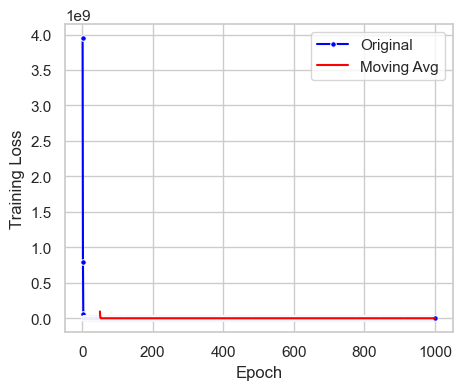

In [18]:
df_loss = pd.DataFrame({
    'Epoch': range(1, max_epochs+1),
    'Training Loss': model.train_loss
})
# Get the initial loss
init_loss = df_loss['Training Loss'].iloc[0]
# Keep only rows where loss is less than or equal to initial loss to facilitate the visualization
df_loss = df_loss[df_loss['Training Loss'] <= init_loss]

window_size = 50
df_loss['MA Training Loss'] = df_loss['Training Loss'].rolling(window=window_size).mean()
df_loss.replace([np.inf, -np.inf], np.nan, inplace=True)

plt.figure(figsize=(5, 4))
sns.set_theme(style="whitegrid")   
sns.lineplot(data=df_loss, x='Epoch', y='Training Loss', marker='o', markersize=4, color='blue', label='Original')
sns.lineplot(data=df_loss, x='Epoch', y='MA Training Loss', color='red', label='Moving Avg')
plt.show()

In [19]:
model.get_corr(num_sim=100, workers=-1, seed=0);

results_metvae = model.sparse_by_p(p_adj_method='fdr_bh', cutoff=0.001)
est_cor = results_metvae['sparse_estimate'].values
feature_names = df_abundance.columns

df_cor = pd.DataFrame(est_cor, index=feature_names, columns=feature_names)

# Get upper triangle mask (excluding diagonal)
df_cor.index.name = None
df_cor.columns.name = None

mask = np.triu(np.ones(df_cor.shape), k=1).astype(bool)
df_cor_upper = df_cor.where(mask)

# Convert to long format
df_long = df_cor_upper.stack().reset_index()
df_long.columns = ['node1', 'node2', 'correlation']

# Sort by correlations
df_long = df_long.sort_values('correlation', key=abs, ascending=False)

df_long.to_csv('../results/intermediate_results/hcc_correlations.csv', index=False)

## Prepare the Graph

In [1]:
import re
import os
import numpy as np
import pandas as pd
import networkx as nx

### Import the original graph

In [2]:
G_cosine_full = nx.read_graphml("../data/hcc/hcc_graph.graphml")

print(G_cosine_full.is_directed())

False


In [3]:
print(f"{G_cosine_full.number_of_nodes()} nodes, {G_cosine_full.number_of_edges()} edges")

# Show edge attributes
edges_cosine_full = nx.to_pandas_edgelist(G_cosine_full)
print("Edge attributes:")
print(list(edges_cosine_full.columns))
print("Cosine score distribution:")
print(edges_cosine_full['cosine_score'].describe())

7713 nodes, 146818 edges
Edge attributes:
['source', 'target', 'property1', 'EdgeScore', 'node1', 'explained_intensity', 'cosine_score', 'component', 'mass_difference', 'EdgeType', 'id', 'EdgeAnnotation', 'node2']
Cosine score distribution:
count    146818.000000
mean          0.646726
std           0.186435
min           0.101400
25%           0.518600
50%           0.634600
75%           0.778400
max           1.000000
Name: cosine_score, dtype: float64


### Create conventional correlation graphs

In [4]:
# Load correlation data
corr_df = pd.read_csv('../results/intermediate_results/hcc_correlations.csv')
corr_df['source'] = corr_df['node1'].astype(str)
corr_df['target'] = corr_df['node2'].astype(str)

corr_df.shape

(26038936, 5)

In [5]:
corr_df['corr_cutoff0.7'] = np.where(corr_df['correlation'].abs() >= 0.7, corr_df['correlation'], 0)
print(f"Number of edges with correlations >= 0.7: {(corr_df['corr_cutoff0.7'] != 0).sum()}")

Number of edges with correlations >= 0.7: 22459


In [6]:
# Create graph for this cutoff
G_corr = nx.Graph()
col = 'corr_cutoff0.7'

# Add edges (filter non-zero correlations)
added = 0
for _, row in corr_df.iterrows():
    u, v, c = row["source"], row["target"], float(row[col])
    if c != 0:
        cutoff_value = col.replace('corr_cutoff', '')
        G_corr.add_edge(
            u, v, 
            EdgeScore=c,
            EdgeType=f'Correlation_cutoff{cutoff_value}',
            id=f'Correlation_cutoff{cutoff_value}'
        )
        added += 1

print(f"\n{col}: Created correlation graph with {added} edges")

# Copy node attributes from the original graph
nodes_updated = 0
for node in G_corr.nodes():
    if node in G_cosine_full.nodes():
        G_corr.nodes[node].update(G_cosine_full.nodes[node])
        nodes_updated += 1

print(f"Updated attributes for {nodes_updated} / {G_corr.number_of_nodes()} nodes")

# Save as GraphML
cutoff_value = col.replace('corr_cutoff', '')
output_file = f"../results/outputs/hcc_correlation_graph_cutoff{cutoff_value}.graphml"
nx.write_graphml(G_corr, output_file)
print(f"Saved: {output_file}")


corr_cutoff0.7: Created correlation graph with 22459 edges
Updated attributes for 3970 / 3970 nodes
Saved: ../results/outputs/hcc_correlation_graph_cutoff0.7.graphml
